<br/>

<div align="center">
<span style="font-size: 2.5em;">Wasserstein Distance Analysis</span>
<br/>
<span style="font-size: 1.2em; color: gray;">Measuring geometric distances between learned and analytical posteriors via optimal transport</span>
</div>

## Overview

The **Wasserstein distance** measures the geometric distance between two probability distributions by solving an optimal transport problem. Unlike divergences (e.g., Jensen-Shannon), it accounts for the underlying sample space geometry, making it particularly valuable for assessing posterior calibration.

Key advantages:
- **Geometric interpretation**: Minimum cost to transport mass from one distribution to the other
- **Zero on identical distributions**: Exactly zero only when distributions are identical
- **Interpretability**: Measured in the original parameter units, not dimensionless

## Mathematical Foundation

### 1-Dimensional Wasserstein Distance

For univariate distributions with quantile functions $F^{-1}_1$ and $F^{-1}_2$:

$$W_1(p_1, p_2) = \int_0^1 |F_1^{-1}(u) - F_2^{-1}(u)| \, du$$

This can be computed exactly via sorted samples in 1D and serves as a baseline metric. The 1D case is particularly elegant because the optimal transport map is monotonic and determined uniquely by the quantile functions—we can sort both sample sets and pair them in order, computing the average distance directly.

### The Monge-Kantorovich Problem in Higher Dimensions

In 2D and beyond, the transport problem becomes vastly more complex. The **Monge problem** asks: what is the optimal transport map $T$ that minimizes the total cost?

$$\min_T \int |x - T(x)| \, p_1(x) \, dx$$

subject to $T_\# p_1 = p_2$ (the pushforward of $p_1$ under $T$ equals $p_2$).

**Why 2D is fundamentally harder than 1D:**

1. **Non-uniqueness of optimal transport**: In 1D, the monotonic coupling is unique. In 2D+, multiple couplings can achieve the same minimum cost (the map is not uniquely determined).

2. **Combinatorial explosion**: With $n$ samples, finding the optimal assignment in 1D is $O(n \log n)$ via sorting. In 2D, this becomes a matching problem with $O(n^3)$ complexity (Hungarian algorithm) or worse for exact solutions.

3. **The Kantorovich relaxation**: Since finding the optimal Monge map is intractable, we relax to the **Kantorovich problem**: finding an optimal *coupling* (joint distribution) $\pi$ rather than a map:

$$W_p(\nu_1, \nu_2) = \left( \inf_\pi \int |x - y|^p \, d\pi(x, y) \right)^{1/p}$$

where the infimum is over all couplings $\pi$ with marginals $p_1$ and $p_2$. This is a linear program but still expensive in high dimensions.

4. **Curse of dimensionality**: The computational cost scales poorly with dimension $d$. Direct computation requires solving a transport problem in $d$-dimensional space, which becomes prohibitively expensive as $d > 2$ or $3$.

### Marginal Wasserstein Distance

For multivariate posteriors, we compute the Wasserstein distance for each parameter independently and report the mean:

$$W^\text{marginal} = \frac{1}{d} \sum_{i=1}^d W_1(p_i^\text{learned}, p_i^\text{analytical})$$

**Interpretation**: Average distance between marginal posteriors across all sampled parameters. Sensitive to shifts and width changes in each dimension.

**Advantages**: Returns to 1D problem for each parameter individually—computationally tractable.

**Limitations**: Ignores joint correlations between parameters; two distributions can have identical marginals but very different joint structure.

### Sliced Wasserstein Distance

To avoid the curse of dimensionality in higher dimensions, the sliced Wasserstein distance averages Wasserstein distances computed along random projections:

$$W_\text{sliced} = \int_{\mathbb{S}^{d-1}} W_1(\theta^T p_\text{learned}, \theta^T p_\text{analytical}) \, d\sigma(\theta)$$

where $\theta$ are random unit vectors on the unit sphere. This metric:
- **Captures joint structure**: Projections along different directions reveal correlations between parameters
- **Scales well to high dimensions**: Each projection is 1D, solved via sorting
- **Approximates full Wasserstein**: Averaging over many random directions provides a good approximation to the true high-dimensional distance
- **Computational feasibility**: With $m$ random projections, complexity is $O(m \cdot n \log n)$, making it practical for moderate $d$

The sliced approach elegantly sidesteps the combinatorial intractability of the full Monge-Kantorovich problem by decomposing the high-dimensional transport into many tractable 1D problems.

In [1]:
# =============================
# IMPORTS AND PATH SETTINGS
# =============================

import os, sys
desired_root_name = "dark-matter-sbi"  
while os.path.basename(os.getcwd()) != desired_root_name:
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch

from data.mc_generator import mc_generator
from configs.config import load_model, PARAM_RANGES
from utils.processing import load_matching_pairs
from performances.metrics import wasserstein_eval_marginals, wasserstein_eval_sliced, plot_wasserstein_diagnostics, plot_wasserstein_marginals
from analytical.ppg_class import PoissonPosteriorGrid

## Model Configuration

In [2]:
# ===========================================
# PARAMETERS TO DEFINE THE DATA AND MODEL 
# ===========================================

modelname = "ntothighest"          
halo      = "default"       
datatag   = "low"
n_train   = 300_000
top_k     = 10              

logm_range = PARAM_RANGES[datatag]["logm_range"]
logcp_range = PARAM_RANGES[datatag]["logcp_range"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


## Data and Model Loading

In [4]:
# =============================
# LOAD MODEL AND CHECKPOINT
# =============================

DATAPATH = f"data/datasets/wimpy/{halo}/wimpy_n{n_train}_{datatag}_{halo}.pt"
MODELPATH = f"models/wimpy/{halo}/{modelname}_n{n_train}_{datatag}_{halo}.pt"

model, ckpt = load_model(MODELPATH, modelname, print_arch=False)
print(f"Loading model from:\n{MODELPATH}\n")

Loading model from:
models/wimpy/default/ntothighest_n300000_low_default.pt



In [5]:
# =====================================
# LOAD TEST AND/OR VALIDATION DATA
# =====================================

X_val, T_val = load_matching_pairs(halo_choice=halo, n_train=n_train, datatag=datatag, split="val")

Loading dataset from:
data/datasets/wimpy/default/wimpy_n300000_low_default.pt



## Marginal Wasserstein Distance Evaluation

In [6]:
resolution = 100 

ppg = PoissonPosteriorGrid.load_or_compute(datatag, resolution, mc_generator)

mean_dists_marginals, results_marginals = wasserstein_eval_marginals(
    model=model, test_features=X_val, test_thetas=T_val, logm_range=logm_range, logcp_range=logcp_range, ppg=ppg, posteriorbins=resolution, n_samples=500
)

###################################################
Mean Wasserstein Distance:
                              Mass     : 0.701
                              Coupling : 0.507
###################################################


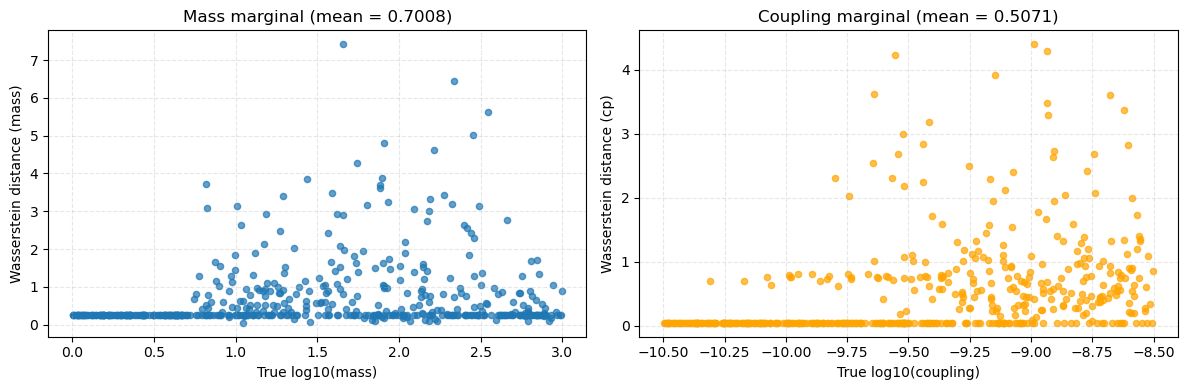

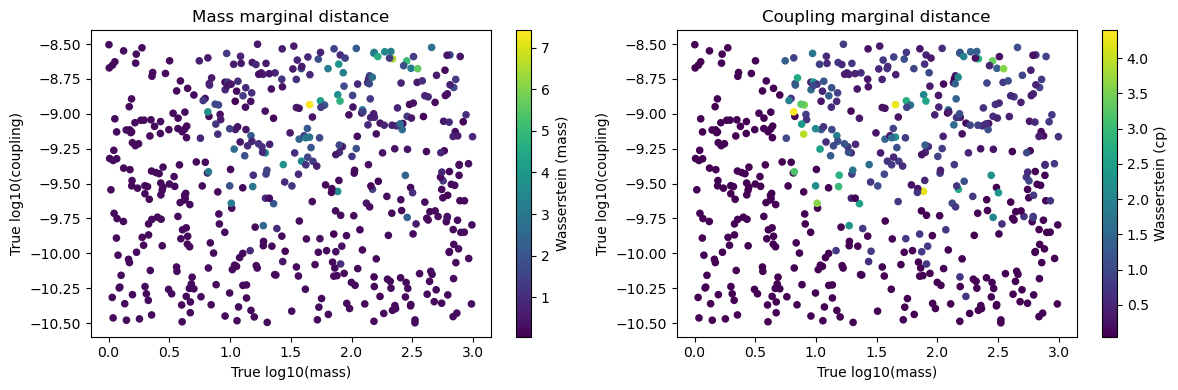

In [7]:
print(
    "###################################################\n"
    f"Mean Wasserstein Distance:\n"
    f"                              Mass     : {mean_dists_marginals['mass']:.3f}\n"
    f"                              Coupling : {mean_dists_marginals['cp']:.3f}"
    "\n###################################################"
)

plot_wasserstein_marginals(results_marginals, mean_dists_marginals, bins=30)

### Interpretation: Exclusion Region

An interesting feature emerges in the parameter space visualizations: for very low masses and very low couplings, the Wasserstein distances approach **nearly zero**. This behavior reveals an **exclusion plot** pattern.

**Physical explanation**: At these low parameter values, the WIMP cross-sections are too small to produce any detectable recoil events. When the model generates zero events, both the analytical posterior and the learned posterior correctly predict zero signal—resulting in perfect agreement and minimal Wasserstein distance.

This phenomenon serves as a **sanity check** for model calibration: the network has learned to correctly identify the exclusion region where no dark matter signal is expected, mirroring the analytical predictions precisely.

## Sliced Wasserstein Distance Evaluation

In [10]:
mean_wass_sliced, results_sliced = wasserstein_eval_sliced(
    model=model, test_features=X_val, test_thetas=T_val, logm_range=logm_range, logcp_range=logcp_range, ppg=ppg, n_samples=2000, n_projections=100
)


###################################################
Mean Wasserstein Distance:
                                   0.590
###################################################


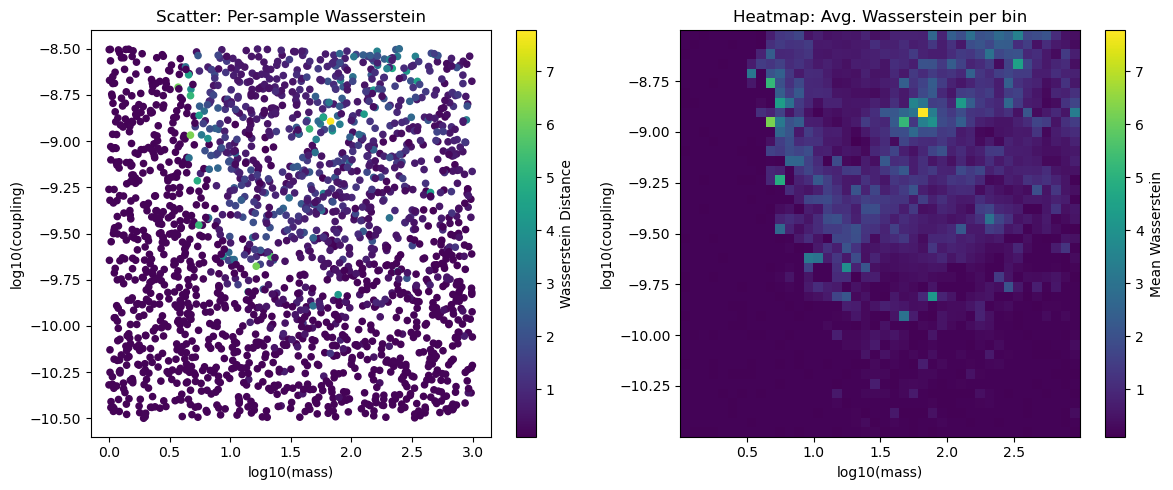

In [15]:
print(
    "###################################################\n"
    "Mean Wasserstein Distance:\n" 
    f"                                   {mean_wass_sliced:.3f}"
    "\n###################################################"
)

plot_wasserstein_diagnostics(results_sliced, bins=42, fill_holes=True)